<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Demography_Migration_MADDPG_GDM_RU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-
"""
Colab-ноутбук для моделирования демографической политики
с использованием многоагентного обучения с подкреплением (MADDPG) и эволюционных алгоритмов.

Основная цель: оптимизация демографической политики в регионах России с помощью
гибридного подхода, сочетающего методы обучения с подкреплением и эволюционные алгоритмы.
"""
# Импорт библиотек для численных вычислений (numpy), работы с данными (pandas)
import numpy as np
import pandas as pd
# Импорт библиотеки PyTorch для создания и обучения нейронных сетей
import torch
import torch.nn as nn # Модули нейронных сетей
import torch.optim as optim # Оптимизаторы
import torch.nn.functional as F # Функции активации и другие функции
# Импорт структур данных (defaultdict, deque) и модуля генерации случайных чисел (random)
from collections import defaultdict, deque
import random
# Импорт модуля для работы с JSON, построения графиков (matplotlib, seaborn)
import json
import matplotlib.pyplot as plt
import seaborn as sns
# Импорт модуля для работы с датами и временем
from datetime import datetime
# Импорт модуля для управления предупреждениями
import warnings
warnings.filterwarnings('ignore') # Игнорировать все предупреждения

# Установка случайных семян для воспроизводимости результатов экспериментов
np.random.seed(42) # Семя для numpy
torch.manual_seed(42) # Семя для PyTorch CPU
random.seed(42) # Семя для стандартного модуля random

In [2]:
class SyntheticDataGenerator:
    """Генератор синтетических данных на основе реальных демографических данных"""
    # Конструктор класса, инициализирует генератор данными
    def __init__(self, real_data_path, crisis_scenarios_path):
        self.df = pd.read_csv(real_data_path) # Загрузка реальных демографических данных из CSV
        # Открытие и загрузка сценариев кризисов из JSON-файла
        with open(crisis_scenarios_path, 'r') as f:
            self.crisis_scenarios = json.load(f)
        self.preprocess_data() # Вызов метода предобработки данных

    # Метод для предобработки реальных данных и вычисления статистик
    def preprocess_data(self):
        """Предобработка реальных данных для моделирования"""
        # Нормализация данных и вычисление статистик
        self.region_stats = {} # Словарь для хранения статистики по регионам
        # Перебор уникальных названий регионов в данных
        for region in self.df['region_name'].unique():
            # Выборка данных только для текущего региона
            region_data = self.df[self.df['region_name'] == region]
            # Вычисление и сохранение статистических показателей для региона
            self.region_stats[region] = {
                'birth_rate_mean': region_data['birth_rate'].mean(), # Среднее значение рождаемости
                'birth_rate_std': region_data['birth_rate'].std(), # Стандартное отклонение рождаемости
                'death_rate_mean': region_data['death_rate'].mean(), # Среднее значение смертности
                'death_rate_std': region_data['death_rate'].std(), # Стандартное отклонение смертности
                'migration_mean': region_data['migration_balance'].mean(), # Среднее значение миграции
                'migration_std': region_data['migration_balance'].std(), # Стандартное отклонение миграции
                'gdp_mean': region_data['gdp_per_capita'].mean(), # Среднее значение ВВП на душу населения
                'gdp_std': region_data['gdp_per_capita'].std(), # Стандартное отклонение ВВП
                'unemployment_mean': region_data['unemployment_rate'].mean(), # Среднее значение безработицы
                'unemployment_std': region_data['unemployment_rate'].std(), # Стандартное отклонение безработицы
                'population_trend': self._calculate_trend(region_data['population']), # Тренд численности населения
                'region_id': region_data['region_id'].iloc[0] # Идентификатор региона
            }

    # Метод для вычисления тренда временного ряда (коэффициент наклона)
    def _calculate_trend(self, series):
        """Вычисление тренда временного ряда"""
        x = np.arange(len(series)) # Создание массива индексов (лет)
        z = np.polyfit(x, series, 1) # Линейная регрессия (полином 1-й степени)
        return z[0]  # Возврат коэффициента наклона

    # Метод для применения влияния кризиса на демографические показатели
    def apply_crisis_impact(self, base_values, crisis_scenario, year, crisis_start_year):
        """Применение влияния кризиса на демографические показатели"""
        crisis_duration = year - crisis_start_year + 1 # Продолжительность кризиса в годах
        max_duration = crisis_scenario['end_year'] - crisis_scenario['start_year'] + 1 # Макс. продолжительность
        # Интенсивность кризиса убывает со временем (от 1 до 0)
        intensity = max(0, 1 - (crisis_duration - 1) / max_duration)
        impacts = crisis_scenario['demographic_impacts'] # Получение воздействий кризиса
        # Вычисление воздействий на каждый показатель
        birth_rate_impact = impacts['birth_rate_change'] * intensity # Воздействие на рождаемость
        death_rate_impact = impacts['death_rate_change'] * intensity # Воздействие на смертность
        migration_impact = impacts['migration_change'] * intensity # Воздействие на миграцию
        economic_impact = impacts['economic_impact'] * intensity # Экономическое воздействие
        modified_values = base_values.copy() # Копия базовых значений для модификации
        # Применение воздействий к показателям
        modified_values['birth_rate'] *= (1 + birth_rate_impact) # Изменение рождаемости
        modified_values['death_rate'] *= (1 + death_rate_impact) # Изменение смертности
        modified_values['migration_balance'] *= (1 + migration_impact) # Изменение миграции
        modified_values['gdp_per_capita'] *= (1 + economic_impact) # Изменение ВВП
        modified_values['unemployment_rate'] *= (1 - economic_impact * 0.5) # Изменение безработицы
        return modified_values # Возврат модифицированных значений

    # Метод для генерации синтетических демографических данных
    def generate_synthetic_data(self, years, regions, apply_crisis=True):
        """Генерация синтетических демографических данных"""
        synthetic_data = [] # Список для хранения сгенерированных данных
        # Перебор всех лет
        for year in years:
            # Перебор всех регионов
            for region in regions:
                # Проверка наличия статистики для региона
                if region not in self.region_stats:
                    continue # Пропустить регион, если статистика отсутствует
                stats = self.region_stats[region] # Получение статистики региона
                # Генерация базовых значений на основе статистики (нормальное распределение)
                base_values = {
                    'region_id': stats['region_id'], # Идентификатор региона
                    'region_name': region, # Название региона
                    'year': year, # Год
                    # Уровень рождаемости (нормальное распределение, не меньше 0)
                    'birth_rate': max(0, np.random.normal(stats['birth_rate_mean'], stats['birth_rate_std'])),
                    # Уровень смертности (нормальное распределение, не меньше 0)
                    'death_rate': max(0, np.random.normal(stats['death_rate_mean'], stats['death_rate_std'])),
                    # Миграционный баланс (нормальное распределение)
                    'migration_balance': np.random.normal(stats['migration_mean'], stats['migration_std']),
                    # ВВП на душу населения (нормальное распределение, не меньше 0)
                    'gdp_per_capita': max(0, np.random.normal(stats['gdp_mean'], stats['gdp_std'])),
                    # Уровень безработицы (нормальное распределение, от 0 до 100)
                    'unemployment_rate': max(0, min(100, np.random.normal(stats['unemployment_mean'], stats['unemployment_std'])))
                }
                # Применение кризисных сценариев, если разрешено
                if apply_crisis:
                    # Перебор всех кризисных сценариев
                    for scenario in self.crisis_scenarios:
                        # Проверка, попадает ли год в период кризиса
                        if scenario['start_year'] <= year <= scenario['end_year']:
                            # Применение влияния кризиса к базовым значениям
                            base_values = self.apply_crisis_impact(
                                base_values, scenario, year, scenario['start_year']
                            )
                # Расчет производных показателей
                # Естественный прирост населения (рождаемость - смертность)
                base_values['natural_increase_rate'] = base_values['birth_rate'] - base_values['death_rate']
                # Базовая численность населения с учетом тренда
                base_population = 1000000 + stats['population_trend'] * (year - 2010)
                # Общая численность населения (не меньше 0)
                base_values['population'] = max(0, int(base_population +
                    (base_values['natural_increase_rate'] + base_values['migration_balance']/1000) * 1000))
                # Средняя зарплата, коррелирующая с ВВП и безработицей
                base_values['average_wage'] = max(0, base_values['gdp_per_capita'] * 0.03 *
                                                (1 - base_values['unemployment_rate']/100))
                synthetic_data.append(base_values) # Добавление сгенерированных данных в список
        # Преобразование списка словарей в DataFrame pandas и возврат
        return pd.DataFrame(synthetic_data)

In [3]:
class DemographicEnvironment:
    """Многоагентная среда для демографического моделирования"""
    # Конструктор класса, инициализирует среду
    def __init__(self, data, n_regions=10, max_steps=50):
        self.data = data # Сохранение демографических данных
        # Получение первых n_regions уникальных названий регионов
        self.regions = data['region_name'].unique()[:n_regions]
        self.n_regions = len(self.regions) # Количество регионов (агентов)
        self.max_steps = max_steps # Максимальное количество шагов в эпизоде
        self.current_step = 0 # Текущий шаг в эпизоде
        # Размерности пространства состояний и действий
        self.state_dim = 8  # основные демографические показатели (8 параметров)
        self.action_dim = 4  # политические действия (4 типа действий)
        self.reset() # Сброс среды к начальному состоянию

    # Метод для сброса среды к начальному состоянию
    def reset(self):
        """Сброс среды к начальному состоянию"""
        self.current_step = 0 # Сброс счетчика шагов
        self.states = {} # Словарь для хранения текущих состояний регионов
        # Словарь для хранения истории каждого региона
        self.histories = {region: [] for region in self.regions}
        # Инициализация состояний всех регионов
        for i, region in enumerate(self.regions):
            # Получение данных для региона на начальный год
            region_data = self.data[self.data['region_name'] == region].iloc[0]
            # Нормализация и сохранение начального состояния региона
            self.states[region] = self._normalize_state(region_data)
        return self.get_observations() # Возврат начальных наблюдений

    # Метод для нормализации состояния региона
    def _normalize_state(self, region_data):
        """Нормализация состояния региона"""
        # Создание нормализованного массива состояния
        return np.array([
            region_data['birth_rate'] / 20.0, # Нормализация рождаемости (до 20)
            region_data['death_rate'] / 30.0, # Нормализация смертности (до 30)
            region_data['natural_increase_rate'] / 10.0, # Нормализация естественного прироста (до 10)
            # Нормализация миграционного баланса (до 100000, максимум 1.0)
            min(region_data['migration_balance'] / 100000.0, 1.0),
            region_data['gdp_per_capita'] / 2000000.0, # Нормализация ВВП на душу (до 2 млн)
            region_data['unemployment_rate'] / 100.0, # Нормализация безработицы (до 100%)
            region_data['population'] / 10000000.0, # Нормализация численности населения (до 10 млн)
            region_data['average_wage'] / 200000.0 # Нормализация средней зарплаты (до 200 тыс)
        ])

    # Метод для получения наблюдений для всех агентов
    def get_observations(self):
        """Получение наблюдений для всех агентов"""
        observations = {} # Словарь для хранения наблюдений
        # Перебор всех регионов
        for region in self.regions:
            # Локальное наблюдение (состояние текущего региона)
            obs = self.states[region].copy()
            # Сбор состояний других регионов
            other_states = [self.states[r] for r in self.regions if r != region]
            # Добавление усредненной информации о других регионах
            if other_states: # Если есть другие регионы
                avg_other = np.mean(other_states, axis=0) # Усреднение их состояний
                obs = np.concatenate([obs, avg_other]) # Объединение локального и среднего состояний
            else: # Если регион один
                obs = np.concatenate([obs, np.zeros(self.state_dim)]) # Добавление нулей
            observations[region] = obs # Сохранение наблюдения для региона
        return observations # Возврат всех наблюдений

    # Метод для выполнения шага в среде
    def step(self, actions):
        """Выполнение шага среды"""
        rewards = {} # Словарь для хранения наград
        # Перебор всех регионов
        for region in self.regions:
            # Проверка, есть ли действие для региона
            if region in actions:
                action = actions[region] # Получение действия
                old_state = self.states[region].copy() # Сохранение старого состояния
                # Обновление состояния региона на основе действия
                self.states[region] = self._apply_policy_action(self.states[region], action)
                # Расчет награды за переход из старого состояния в новое
                rewards[region] = self._calculate_reward(old_state, self.states[region])
                # Сохранение истории шага
                self.histories[region].append({
                    'step': self.current_step, # Номер шага
                    'state': old_state.copy(), # Старое состояние
                    'action': action.copy(), # Выполненное действие
                    'reward': rewards[region] # Полученная награда
                })
        self.current_step += 1 # Увеличение счетчика шагов
        done = self.current_step >= self.max_steps # Проверка завершения эпизода
        # Возврат новых наблюдений, наград, флага завершения и пустого словаря
        return self.get_observations(), rewards, done, {}

    # Метод для применения политических действий к состоянию региона
    def _apply_policy_action(self, state, action):
        """Применение политических действий к состоянию региона"""
        new_state = state.copy() # Копия текущего состояния
        # action[0] - материнский капитал (влияет на рождаемость)
        # action[1] - здравоохранение (влияет на смертность)
        # action[2] - миграционная политика (влияет на миграцию)
        # action[3] - экономические стимулы (влияет на ВВП и безработицу)
        birth_rate_change = action[0] * 0.1 # Изменение рождаемости от маткапитала
        death_rate_change = -action[1] * 0.05 # Изменение смертности от здравоохранения
        migration_change = action[2] * 0.05 # Изменение миграции от миграционной политики
        economic_change = action[3] * 0.02 # Изменение экономических показателей
        # Обновление показателей с учетом действий и ограничений (не меньше 0)
        new_state[0] = max(0, new_state[0] + birth_rate_change)  # birth_rate
        new_state[1] = max(0, new_state[1] + death_rate_change)  # death_rate
        new_state[2] = new_state[0] - new_state[1]  # natural_increase_rate (пересчет)
        new_state[3] = new_state[3] + migration_change  # migration_balance
        new_state[4] = max(0, new_state[4] + economic_change)  # gdp_per_capita
        # Обновление безработицы (от 0 до 1)
        new_state[5] = max(0, min(1, new_state[5] - economic_change * 0.5))  # unemployment_rate
        # Обновление численности населения
        population_change = (new_state[2] + new_state[3]) * 0.01
        new_state[6] = max(0, new_state[6] + population_change) # population
        # Обновление средней зарплаты
        new_state[7] = new_state[4] * 0.1 * (1 - new_state[5]) # average_wage
        return new_state # Возврат нового состояния

    # Метод для расчета награды на основе улучшения демографических показателей
    def _calculate_reward(self, old_state, new_state):
        """Расчет награды на основе улучшения демографических показателей"""
        # Положительные изменения показателей (с весами)
        birth_rate_improvement = (new_state[0] - old_state[0]) * 10 # Улучшение рождаемости
        death_rate_improvement = (old_state[1] - new_state[1]) * 10 # Улучшение смертности
        natural_increase_improvement = (new_state[2] - old_state[2]) * 15 # Улучшение естественного прироста
        migration_improvement = (new_state[3] - old_state[3]) * 5 # Улучшение миграции
        gdp_improvement = (new_state[4] - old_state[4]) * 5 # Улучшение ВВП
        unemployment_improvement = (old_state[5] - new_state[5]) * 5 # Улучшение безработицы
        # Штраф за нестабильность численности населения
        population_stability = -abs(new_state[6] - old_state[6]) * 2
        # Суммирование всех компонентов награды
        total_reward = (birth_rate_improvement + death_rate_improvement +
                       natural_increase_improvement + migration_improvement +
                       gdp_improvement + unemployment_improvement + population_stability)
        return total_reward # Возврат общей награды

In [4]:
class ActorNetwork(nn.Module):
    """Сеть актора для MADDPG"""
    # Конструктор сети актора
    def __init__(self, input_dim, action_dim, hidden_dim=256):
        super(ActorNetwork, self).__init__() # Вызов конструктора родительского класса
        # Полносвязные слои
        self.fc1 = nn.Linear(input_dim, hidden_dim) # Первый скрытый слой
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) # Второй скрытый слой
        self.fc3 = nn.Linear(hidden_dim, action_dim) # Выходной слой (размер действий)
        self.dropout = nn.Dropout(0.1) # Слой Dropout для регуляризации

    # Метод прямого распространения (вычисление действия)
    def forward(self, state):
        x = F.relu(self.fc1(state)) # Применение ReLU к первому слою
        x = self.dropout(x) # Применение Dropout
        x = F.relu(self.fc2(x)) # Применение ReLU ко второму слою
        x = torch.tanh(self.fc3(x)) # Применение Tanh к выходу (действия от -1 до 1)
        return x # Возврат действия

class CriticNetwork(nn.Module):
    """Сеть критика для MADDPG"""
    # Конструктор сети критика
    def __init__(self, state_dim, action_dim, n_agents, hidden_dim=256):
        super(CriticNetwork, self).__init__() # Вызов конструктора родительского класса
        # Вычисление размера входа (состояния и действия всех агентов)
        total_input_dim = state_dim * n_agents + action_dim * n_agents
        # Полносвязные слои
        self.fc1 = nn.Linear(total_input_dim, hidden_dim) # Первый скрытый слой
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) # Второй скрытый слой
        self.fc3 = nn.Linear(hidden_dim, 1) # Выходной слой (оценка Q-значения)
        self.dropout = nn.Dropout(0.1) # Слой Dropout для регуляризации

    # Метод прямого распространения (вычисление Q-значения)
    def forward(self, states, actions):
        # Объединение тензоров состояний и действий
        x = torch.cat([states, actions], dim=1)
        x = F.relu(self.fc1(x)) # Применение ReLU к первому слою
        x = self.dropout(x) # Применение Dropout
        x = F.relu(self.fc2(x)) # Применение ReLU ко второму слою
        return self.fc3(x) # Возврат Q-значения

In [5]:
class MADDPGAgent:
    """Агент MADDPG"""
    # Конструктор агента
    def __init__(self, agent_id, state_dim, action_dim, n_agents, lr_actor=1e-4, lr_critic=1e-3):
        self.agent_id = agent_id # Идентификатор агента
        self.state_dim = state_dim # Размерность состояния
        self.action_dim = action_dim # Размерность действия
        self.n_agents = n_agents # Количество агентов в среде
        # Сети актора (основная и целевая)
        self.actor = ActorNetwork(state_dim, action_dim) # Основная сеть актора
        self.actor_target = ActorNetwork(state_dim, action_dim) # Целевая сеть актора
        # Оптимизатор для сети актора
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        # Сети критика (основная и целевая)
        self.critic = CriticNetwork(state_dim, action_dim, n_agents) # Основная сеть критика
        self.critic_target = CriticNetwork(state_dim, action_dim, n_agents) # Целевая сеть критика
        # Оптимизатор для сети критика
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)
        # Инициализация целевых сетей копированием весов основных сетей
        self.hard_update(self.actor_target, self.actor)
        self.hard_update(self.critic_target, self.critic)
        # Параметры обучения
        self.gamma = 0.95 # Коэффициент дисконтирования
        self.tau = 0.02 # Параметр мягкого обновления

    # Метод для выбора действия агентом
    def act(self, state, noise_scale=0.1):
        """Выбор действия с шумом для исследования"""
        # Преобразование состояния в тензор и добавление размерности батча
        state = torch.FloatTensor(state).unsqueeze(0)
        # Получение действия от сети актора (без градиентов)
        action = self.actor(state).squeeze(0).detach().numpy()
        # Добавление шума для исследования
        noise = np.random.normal(0, noise_scale, size=action.shape)
        # Ограничение действия диапазоном [-1, 1] и добавление шума
        action = np.clip(action + noise, -1, 1)
        return action # Возврат действия

    # Метод для жесткого обновления целевой сети
    def hard_update(self, target, source):
        """Жесткое обновление параметров целевой сети"""
        # Перебор параметров целевой и исходной сетей
        for target_param, param in zip(target.parameters(), source.parameters()):
            # Копирование значения параметра из исходной сети в целевую
            target_param.data.copy_(param.data)

    # Метод для мягкого обновления целевой сети
    def soft_update(self, target, source):
        """Мягкое обновление параметров целевой сети"""
        # Перебор параметров целевой и исходной сетей
        for target_param, param in zip(target.parameters(), source.parameters()):
            # Мягкое обновление: новый параметр = (1-tau)*старый + tau*новый
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)

In [6]:
class EvolutionaryBooster:
    """Эволюционный бустер для оптимизации MARL агентов"""
    # Конструктор эволюционного бустера
    def __init__(self, population_size=20, mutation_rate=0.1, crossover_rate=0.7):
        self.population_size = population_size # Размер популяции
        self.mutation_rate = mutation_rate # Вероятность мутации
        self.crossover_rate = crossover_rate # Вероятность скрещивания
        self.population = [] # Список для хранения агентов популяции
        self.fitness_history = [] # Список для хранения истории фитнеса

    # Метод для инициализации популяции агентов
    def initialize_population(self, agent_template):
        """Инициализация популяции агентов"""
        self.population = [] # Очистка текущей популяции
        # Создание агентов для популяции
        for _ in range(self.population_size):
            agent_copy = self._copy_agent(agent_template) # Создание копии шаблона
            self._mutate_agent(agent_copy, mutation_strength=0.3) # Мутация копии
            self.population.append(agent_copy) # Добавление агента в популяцию

    # Метод для создания копии агента
    def _copy_agent(self, agent):
        """Создание копии агента"""
        # Создание нового агента с теми же параметрами
        new_agent = MADDPGAgent(agent.agent_id, agent.state_dim, agent.action_dim, agent.n_agents)
        # Копирование весов сетей актора и критика
        new_agent.actor.load_state_dict(agent.actor.state_dict())
        new_agent.critic.load_state_dict(agent.critic.state_dict())
        return new_agent # Возврат копии агента

    # Метод для мутации параметров агента
    def _mutate_agent(self, agent, mutation_strength=0.1):
        """Мутация параметров агента"""
        # Мутация параметров сети актора
        for param in agent.actor.parameters():
            # Проверка вероятности мутации
            if np.random.random() < self.mutation_rate:
                # Генерация шума и добавление его к параметру
                noise = torch.randn_like(param) * mutation_strength
                param.data += noise
        # Мутация параметров сети критика
        for param in agent.critic.parameters():
            # Проверка вероятности мутации
            if np.random.random() < self.mutation_rate:
                # Генерация шума и добавление его к параметру
                noise = torch.randn_like(param) * mutation_strength
                param.data += noise

    # Метод для скрещивания двух агентов
    def _crossover_agents(self, parent1, parent2):
        """Скрещивание двух агентов"""
        child1 = self._copy_agent(parent1) # Создание копии первого родителя
        child2 = self._copy_agent(parent2) # Создание копии второго родителя
        # Скрещивание параметров актора
        for p1, p2, c1, c2 in zip(parent1.actor.parameters(), parent2.actor.parameters(),
                                  child1.actor.parameters(), child2.actor.parameters()):
            # Проверка вероятности скрещивания
            if np.random.random() < self.crossover_rate:
                # Создание маски для выбора параметров от родителей
                mask = torch.rand_like(p1) > 0.5
                # Обмен параметрами между потомками по маске
                c1.data = torch.where(mask, p1.data, p2.data)
                c2.data = torch.where(mask, p2.data, p1.data)
        return child1, child2 # Возврат двух потомков

    # Метод для эволюции популяции на основе фитнес-функции
    def evolve_population(self, fitness_scores):
        """Эволюция популяции на основе фитнес-функции"""
        # Объединение агентов и их фитнеса, сортировка по фитнесу (по убыванию)
        population_fitness = list(zip(self.population, fitness_scores))
        population_fitness.sort(key=lambda x: x[1], reverse=True)
        # Отбор лучших особей (элита)
        elite_size = self.population_size // 4 # Размер элиты (1/4 популяции)
        elite = [agent for agent, _ in population_fitness[:elite_size]] # Выбор элиты
        # Создание нового поколения
        new_population = elite.copy() # Начало нового поколения с элиты
        # Заполнение популяции до нужного размера
        while len(new_population) < self.population_size:
            # Турнирный отбор родителей
            parent1 = self._tournament_selection(population_fitness)
            parent2 = self._tournament_selection(population_fitness)
            # Проверка вероятности скрещивания
            if np.random.random() < self.crossover_rate:
                # Скрещивание родителей
                child1, child2 = self._crossover_agents(parent1, parent2)
                # Мутация потомков
                self._mutate_agent(child1)
                self._mutate_agent(child2)
                # Добавление потомков в новое поколение
                new_population.extend([child1, child2])
            else:
                # Если скрещивание не происходит, создается мутировавшая копия
                child = self._copy_agent(parent1) # Копия первого родителя
                self._mutate_agent(child) # Мутация копии
                new_population.append(child) # Добавление мутировавшей копии
        # Обрезка популяции до нужного размера и обновление
        self.population = new_population[:self.population_size]
        # Сохранение истории фитнеса (лучший фитнес текущего поколения)
        self.fitness_history.append(max(fitness_scores))
        return self.population[0]  # Возврат лучшего агента (первого в отсортированном списке)

    # Метод для турнирного отбора родителя
    def _tournament_selection(self, population_fitness, tournament_size=3):
        """Турнирный отбор"""
        # Выбор случайных участников турнира
        tournament = random.sample(population_fitness, min(tournament_size, len(population_fitness)))
        # Возврат агента с наивысшим фитнесом из турнира
        return max(tournament, key=lambda x: x[1])[0]

In [7]:
class ExperimentLogger:
    """Логгер для записи и визуализации результатов экспериментов"""
    # Конструктор логгера
    def __init__(self):
        self.metrics = defaultdict(list) # Словарь для хранения основных метрик
        self.episode_rewards = defaultdict(list) # Словарь для хранения наград по эпизодам
        self.evolution_history = [] # Список для хранения истории эволюции

    # Метод для логирования результатов эпизода
    def log_episode(self, episode, agent_rewards, avg_reward, stability_metric):
        """Логирование эпизода"""
        self.metrics['episode'].append(episode) # Номер эпизода
        self.metrics['avg_reward'].append(avg_reward) # Средняя награда
        self.metrics['stability'].append(stability_metric) # Метрика стабильности
        # Сохранение наград для каждого агента
        for agent_id, reward in agent_rewards.items():
            self.episode_rewards[agent_id].append(reward)

    # Метод для логирования результатов эволюции
    def log_evolution(self, generation, best_fitness, avg_fitness):
        """Логирование эволюции"""
        # Добавление записи о поколении в историю эволюции
        self.evolution_history.append({
            'generation': generation, # Номер поколения
            'best_fitness': best_fitness, # Лучший фитнес
            'avg_fitness': avg_fitness # Средний фитнес
        })

    # Метод для визуализации результатов
    def plot_results(self):
        """Визуализация результатов"""
        plt.figure(figsize=(15, 10)) # Создание фигуры для графиков
        # График 1: Средняя награда по эпизодам
        plt.subplot(2, 3, 1)
        plt.plot(self.metrics['episode'], self.metrics['avg_reward'])
        plt.title('Средняя награда по эпизодам')
        plt.xlabel('Эпизод')
        plt.ylabel('Средняя награда')
        plt.grid(True)
        # График 2: Метрика стабильности
        plt.subplot(2, 3, 2)
        plt.plot(self.metrics['episode'], self.metrics['stability'])
        plt.title('Метрика стабильности')
        plt.xlabel('Эпизод')
        plt.ylabel('Стабильность')
        plt.grid(True)
        # График 3: Награды по агентам (первые 50 эпизодов)
        plt.subplot(2, 3, 3)
        for agent_id, rewards in self.episode_rewards.items():
            plt.plot(rewards[:50], label=f'Agent {agent_id}', alpha=0.7)
        plt.title('Награды по агентам (первые 50 эпизодов)')
        plt.xlabel('Эпизод')
        plt.ylabel('Награда')
        plt.legend()
        plt.grid(True)
        # График 4: Эволюция популяции (если есть данные)
        if self.evolution_history:
            plt.subplot(2, 3, 4)
            # Извлечение данных для графика
            generations = [x['generation'] for x in self.evolution_history]
            best_fitness = [x['best_fitness'] for x in self.evolution_history]
            avg_fitness = [x['avg_fitness'] for x in self.evolution_history]
            # Построение графиков лучшего и среднего фитнеса
            plt.plot(generations, best_fitness, label='Лучший фитнес', linewidth=2)
            plt.plot(generations, avg_fitness, label='Средний фитнес', alpha=0.7)
            plt.title('Эволюция популяции')
            plt.xlabel('Поколение')
            plt.ylabel('Фитнес')
            plt.legend()
            plt.grid(True)
        # График 5: Распределение наград
        plt.subplot(2, 3, 5)
        all_rewards = [] # Список всех наград
        # Сбор наград от всех агентов
        for rewards in self.episode_rewards.values():
            all_rewards.extend(rewards)
        # Построение гистограммы распределения наград
        plt.hist(all_rewards, bins=30, alpha=0.7, edgecolor='black')
        plt.title('Распределение наград')
        plt.xlabel('Награда')
        plt.ylabel('Частота')
        plt.grid(True)
        # График 6: Скользящее среднее наград
        plt.subplot(2, 3, 6)
        window_size = 10 # Размер окна для скользящего среднего
        # Проверка достаточности данных
        if len(self.metrics['avg_reward']) >= window_size:
            # Вычисление скользящего среднего
            moving_avg = pd.Series(self.metrics['avg_reward']).rolling(window=window_size).mean()
            plt.plot(self.metrics['episode'], moving_avg)
            plt.title(f'Скользящее среднее наград (окно {window_size})')
            plt.xlabel('Эпизод')
            plt.ylabel('Скользящее среднее')
            plt.grid(True)
        plt.tight_layout() # Автоматическая настройка расположения графиков
        plt.show() # Отображение графиков

    # Метод для сохранения результатов в CSV-файл
    def save_results(self, filename):
        """Сохранение результатов в CSV"""
        results_df = pd.DataFrame(self.metrics) # Создание DataFrame из метрик
        results_df.to_csv(filename, index=False) # Сохранение в CSV без индекса
        print(f"Результаты сохранены в {filename}") # Вывод сообщения о сохранении

In [8]:
# Основная функция обучения MADDPG с эволюционными бустерами
def train_maddpg_with_evolution(env, n_episodes=200, evolution_frequency=50,
                              population_size=10, save_results=True):
    """Основная функция обучения MADDPG с эволюционными бустерами"""
    print("Инициализация системы обучения...") # Вывод сообщения о начале инициализации
    # Инициализация агентов для каждого региона
    agents = {}
    for i, region in enumerate(env.regions): # Перебор регионов среды
        # Создание агента MADDPG для региона
        agents[region] = MADDPGAgent(
            agent_id=i, # Идентификатор агента
            state_dim=env.state_dim * 2,  # локальное + глобальное состояние (удвоенная размерность)
            action_dim=env.action_dim, # Размерность действия
            n_agents=env.n_regions # Количество агентов
        )
    # Инициализация эволюционных бустеров для каждого региона
    evolution_boosters = {}
    for region in env.regions: # Перебор регионов
        # Создание эволюционного бустера
        booster = EvolutionaryBooster(population_size=population_size)
        # Инициализация популяции агентов на основе шаблона
        booster.initialize_population(agents[region])
        evolution_boosters[region] = booster # Сохранение бустера
    # Создание буферов памяти для каждого агента (для опыта воспроизведения)
    replay_buffers = {region: deque(maxlen=10000) for region in env.regions}
    # Создание логгера результатов
    logger = ExperimentLogger()
    print(f"Начало обучения на {n_episodes} эпизодов...") # Вывод сообщения о начале обучения
    # Основной цикл обучения по эпизодам
    for episode in range(n_episodes):
        states = env.reset() # Сброс среды и получение начальных состояний
        # Словарь для хранения суммарных наград по эпизоду для каждого агента
        episode_rewards = {region: 0 for region in env.regions}
        # Цикл шагов внутри эпизода
        for step in range(env.max_steps):
            # Выбор действий всеми агентами
            actions = {}
            for region in env.regions: # Перебор регионов
                # Агент выбирает действие с шумом для исследования
                action = agents[region].act(states[region], noise_scale=0.1)
                actions[region] = action # Сохранение действия
            # Выполнение шага в среде
            next_states, rewards, done, _ = env.step(actions)
            # Сохранение опыта в буферы памяти
            for region in env.regions: # Перебор регионов
                # Добавление перехода в буфер памяти агента
                replay_buffers[region].append((
                    states[region], actions[region], rewards[region],
                    next_states[region], done
                ))
                # Накопление награды за эпизод
                episode_rewards[region] += rewards[region]
            states = next_states # Обновление состояний
            if done: # Проверка завершения эпизода
                break
        # Обучение агентов (каждые 10 эпизодов, начиная с 10-го)
        if episode % 10 == 0 and episode > 0:
            for region in env.regions: # Перебор регионов
                # Проверка достаточности опыта в буфере
                if len(replay_buffers[region]) > 100:
                    # Обучение агента на батче из буфера
                    _train_agent(agents[region], replay_buffers[region], batch_size=32)
        # Эволюционная оптимизация (с заданной частотой, начиная с первой оптимизации)
        if episode % evolution_frequency == 0 and episode > 0:
            print(f"Эволюционная оптимизация на эпизоде {episode}...") # Вывод сообщения
            for region in env.regions: # Перебор регионов
                # Оценка фитнеса всей популяции
                fitness_scores = []
                for agent in evolution_boosters[region].population: # Перебор агентов популяции
                    # Оценка фитнеса агента
                    fitness = _evaluate_agent_fitness(agent, env, region)
                    fitness_scores.append(fitness) # Сохранение фитнеса
                # Эволюция популяции и получение лучшего агента
                best_agent = evolution_boosters[region].evolve_population(fitness_scores)
                agents[region] = best_agent # Замена текущего агента лучшим из популяции
                # Логирование результатов эволюции
                logger.log_evolution(
                    episode // evolution_frequency, # Номер поколения
                    max(fitness_scores), # Лучший фитнес
                    np.mean(fitness_scores) # Средний фитнес
                )
        # Логирование результатов эпизода
        avg_reward = np.mean(list(episode_rewards.values())) # Средняя награда по агентам
        stability_metric = _calculate_stability_metric(env) # Расчет метрики стабильности
        # Сохранение метрик эпизода
        logger.log_episode(episode, episode_rewards, avg_reward, stability_metric)
        # Вывод прогресса (каждые 20 эпизодов)
        if episode % 20 == 0:
            print(f"Эпизод {episode}, средняя награда: {avg_reward:.3f}, "
                  f"стабильность: {stability_metric:.3f}")
    print("Обучение завершено!") # Вывод сообщения о завершении обучения
    # Визуализация и сохранение результатов
    logger.plot_results() # Построение графиков
    if save_results: # Если нужно сохранить результаты
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S") # Получение временной метки
        logger.save_results(f"maddpg_evolution_results_{timestamp}.csv") # Сохранение в CSV
    return agents, logger # Возврат обученных агентов и логгера

# Функция для обучения отдельного агента MADDPG
def _train_agent(agent, replay_buffer, batch_size=32):
    """Обучение отдельного агента MADDPG"""
    # Проверка достаточности опыта в буфере
    if len(replay_buffer) < batch_size:
        return # Выход, если недостаточно опыта
    # Выборка случайного батча из буфера
    batch = random.sample(replay_buffer, batch_size)
    # Разделение батча на компоненты
    states = torch.FloatTensor([x[0] for x in batch]) # Состояния
    actions = torch.FloatTensor([x[1] for x in batch]) # Действия
    rewards = torch.FloatTensor([x[2] for x in batch]).unsqueeze(1) # Награды
    next_states = torch.FloatTensor([x[3] for x in batch]) # Следующие состояния
    dones = torch.BoolTensor([x[4] for x in batch]).unsqueeze(1) # Флаги завершения
    # Обновление критика
    with torch.no_grad(): # Отключение градиентов для вычисления целевого значения
        # Получение действий от целевой сети актора для следующих состояний
        next_actions = agent.actor_target(next_states)
        # Подготовка глобальных состояний и действий для критика (дублирование для всех агентов)
        global_next_states = next_states.repeat(1, agent.n_agents).view(batch_size, -1)
        global_next_actions = next_actions.repeat(1, agent.n_agents).view(batch_size, -1)
        # Получение целевого Q-значения от целевой сети критика
        target_q = agent.critic_target(global_next_states, global_next_actions)
        # Вычисление целевого значения с учетом награды и дисконтирования
        target_q = rewards + agent.gamma * target_q * (~dones)
    # Подготовка текущих глобальных состояний и действий для основной сети критика
    global_states = states.repeat(1, agent.n_agents).view(batch_size, -1)
    global_actions = actions.repeat(1, agent.n_agents).view(batch_size, -1)
    # Получение текущего Q-значения от основной сети критика
    current_q = agent.critic(global_states, global_actions)
    # Вычисление функции потерь для критика (MSE между текущим и целевым Q)
    critic_loss = F.mse_loss(current_q, target_q)
    # Обнуление градиентов оптимизатора критика
    agent.critic_optimizer.zero_grad()
    # Вычисление градиентов функции потерь
    critic_loss.backward()
    # Обрезка градиентов для стабильности обучения
    torch.nn.utils.clip_grad_norm_(agent.critic.parameters(), 0.5)
    # Шаг оптимизации для сети критика
    agent.critic_optimizer.step()
    # Обновление актора
    # Получение предсказанных действий от основной сети актора
    predicted_actions = agent.actor(states)
    # Подготовка глобальных предсказанных действий
    global_predicted_actions = predicted_actions.repeat(1, agent.n_agents).view(batch_size, -1)
    # Вычисление функции потерь для актора (минус среднее Q-значение)
    actor_loss = -agent.critic(global_states, global_predicted_actions).mean()
    # Обнуление градиентов оптимизатора актора
    agent.actor_optimizer.zero_grad()
    # Вычисление градиентов функции потерь
    actor_loss.backward()
    # Обрезка градиентов для стабильности обучения
    torch.nn.utils.clip_grad_norm_(agent.actor.parameters(), 0.5)
    # Шаг оптимизации для сети актора
    agent.actor_optimizer.step()
    # Мягкое обновление целевых сетей
    agent.soft_update(agent.actor_target, agent.actor) # Для актора
    agent.soft_update(agent.critic_target, agent.critic) # Для критика

# Функция для оценки фитнеса агента
def _evaluate_agent_fitness(agent, env, region, n_eval_episodes=3):
    """Оценка фитнеса агента"""
    total_reward = 0 # Инициализация суммарной награды
    # Цикл по эпизодам оценки
    for _ in range(n_eval_episodes):
        states = env.reset() # Сброс среды
        episode_reward = 0 # Инициализация награды за эпизод
        # Цикл шагов в эпизоде оценки
        for _ in range(env.max_steps):
            # Агент выбирает действие без шума для оценки
            action = agent.act(states[region], noise_scale=0.0)
            actions = {region: action} # Действие оцениваемого агента
            # Добавление случайных действий для других агентов (имитация среды)
            for other_region in env.regions:
                if other_region != region: # Для всех регионов, кроме оцениваемого
                    actions[other_region] = np.random.uniform(-1, 1, env.action_dim)
            # Выполнение шага
            next_states, rewards, done, _ = env.step(actions)
            # Накопление награды оцениваемого агента
            episode_reward += rewards.get(region, 0)
            states = next_states # Обновление состояний
            if done: # Проверка завершения
                break
        total_reward += episode_reward # Добавление награды эпизода к общей сумме
    # Возврат средней награды по эпизодам оценки
    return total_reward / n_eval_episodes

# Функция для расчета метрики стабильности демографической системы
def _calculate_stability_metric(env):
    """Расчет метрики стабильности демографической системы"""
    stability_scores = [] # Список для хранения оценок стабильности регионов
    for region in env.regions: # Перебор регионов
        state = env.states[region] # Получение текущего состояния региона
        # Расчет стабильности как среднего трех компонентов:
        # 1. Баланс рождаемости и смертности (меньше - лучше)
        natural_balance = abs(state[2])  # natural_increase_rate
        # 2. Экономическая стабильность (меньше безработицы - лучше)
        economic_stability = 1 - state[5]  # unemployment_rate
        # 3. Миграционная стабильность (меньше абсолютного значения миграции - лучше)
        migration_stability = 1 / (1 + abs(state[3]) * 10)  # migration_balance
        # Средняя оценка стабильности региона
        region_stability = (natural_balance + economic_stability + migration_stability) / 3
        stability_scores.append(region_stability) # Добавление в список
    return np.mean(stability_scores) # Возврат средней стабильности по регионам

=== СИСТЕМА МНОГОАГЕНТНОГО ОБУЧЕНИЯ С ПОДКРЕПЛЕНИЕМ ===
=== ДЛЯ ДЕМОГРАФИЧЕСКОГО МОДЕЛИРОВАНИЯ РЕГИОНОВ РОССИИ ===

Генерация синтетических данных...
Сгенерировано 50 записей для 10 регионов
Создание многоагентной среды...
Среда создана для 8 регионов: ['Moscow', 'St. Petersburg', 'Tatarstan', 'Krasnodar Krai', 'Sverdlovsk Oblast', 'Novosibirsk Oblast', 'Samara Oblast', 'Rostov Oblast']
Запуск эксперимента MADDPG с эволюционными бустерами...
Инициализация системы обучения...
Начало обучения на 100 эпизодов...
Эпизод 0, средняя награда: 14.458, стабильность: 0.665
Эпизод 20, средняя награда: 13.291, стабильность: 0.627
Эволюционная оптимизация на эпизоде 25...
Эпизод 40, средняя награда: 35.101, стабильность: 0.645
Эволюционная оптимизация на эпизоде 50...
Эпизод 60, средняя награда: 37.129, стабильность: 0.672
Эволюционная оптимизация на эпизоде 75...
Эпизод 80, средняя награда: 50.150, стабильность: 0.727
Обучение завершено!


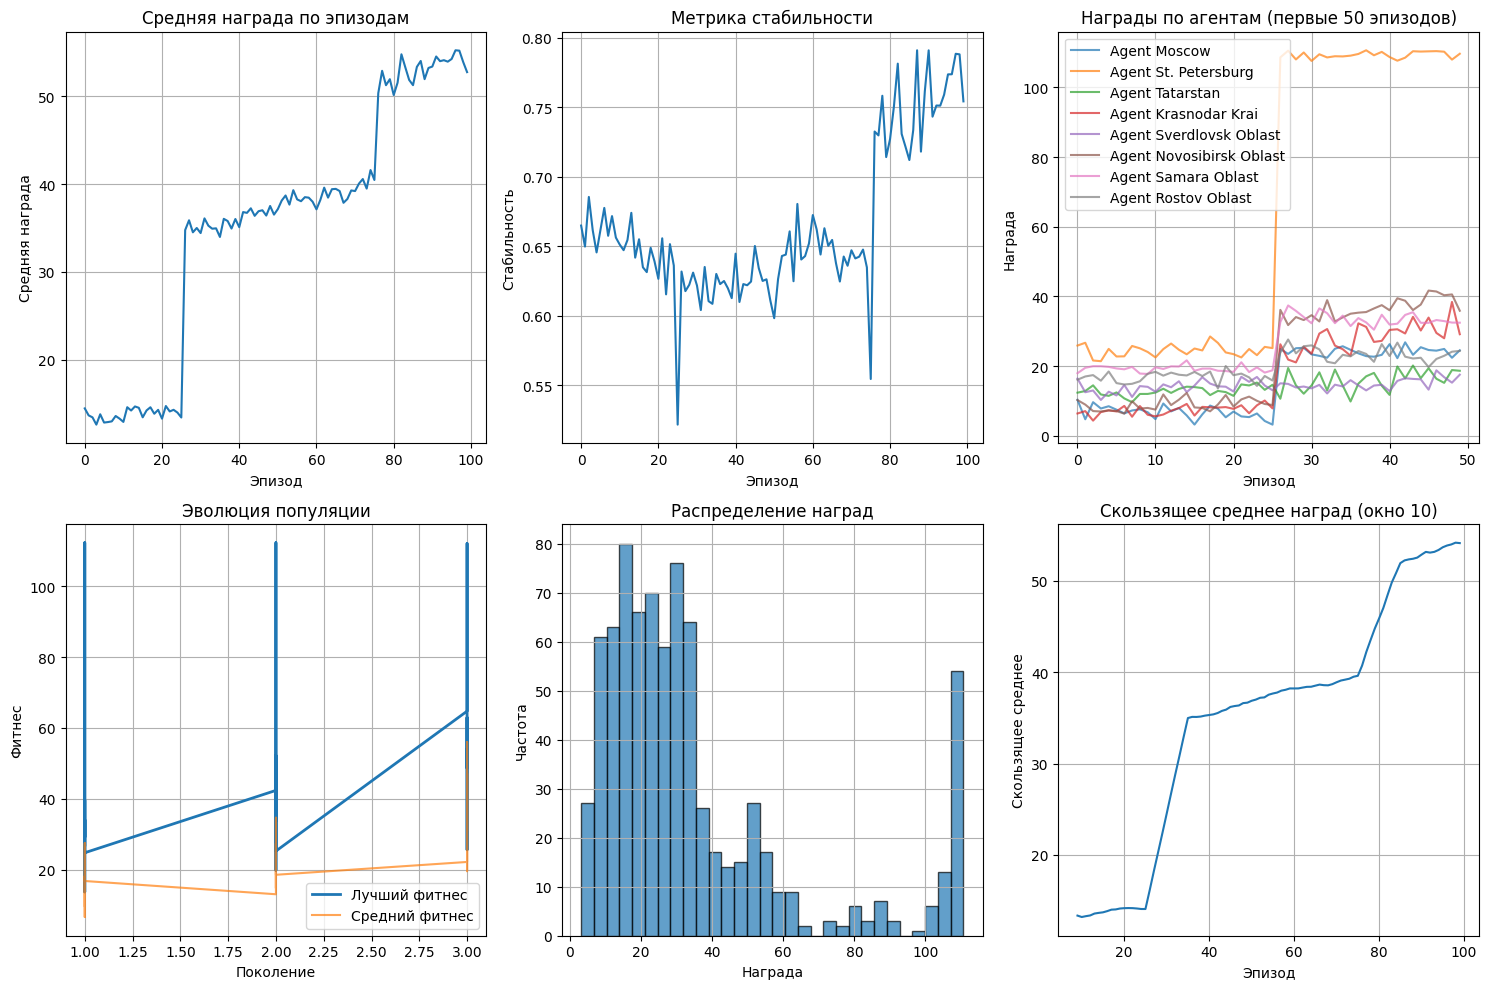

Результаты сохранены в maddpg_evolution_results_20250904_144752.csv

=== ЭКСПЕРИМЕНТ ЗАВЕРШЕН ===
Обучено 8 агентов
Результаты визуализированы и сохранены

=== ИТОГОВАЯ ОЦЕНКА ===
Регион Moscow: финальный фитнес = 68.847
Регион St. Petersburg: финальный фитнес = 111.164
Регион Tatarstan: финальный фитнес = 56.946
Регион Krasnodar Krai: финальный фитнес = 57.884
Регион Sverdlovsk Oblast: финальный фитнес = 31.710
Регион Novosibirsk Oblast: финальный фитнес = 66.367
Регион Samara Oblast: финальный фитнес = 52.138
Регион Rostov Oblast: финальный фитнес = 51.375
Средний финальный фитнес: 62.054
Стандартное отклонение: 21.369


In [9]:
# Демонстрация использования системы (выполняется при запуске скрипта как основной)
if __name__ == "__main__":
    print("=== СИСТЕМА МНОГОАГЕНТНОГО ОБУЧЕНИЯ С ПОДКРЕПЛЕНИЕМ ===")
    print("=== ДЛЯ ДЕМОГРАФИЧЕСКОГО МОДЕЛИРОВАНИЯ РЕГИОНОВ РОССИИ ===")
    print()
    # Генерация синтетических данных
    print("Генерация синтетических данных...")
    # Создание генератора данных
    data_generator = SyntheticDataGenerator(
        'russian_regions_demographic_data_2010_2024.csv', # Путь к реальным данным
        'crisis.txt' # Путь к сценариям кризисов
    )
    # Генерация данных для экспериментов
    years = list(range(2020, 2025)) # Годы для генерации
    # Список топ регионов для моделирования
    top_regions = ['Moscow', 'St. Petersburg', 'Tatarstan', 'Krasnodar Krai',
                   'Sverdlovsk Oblast', 'Novosibirsk Oblast', 'Samara Oblast',
                   'Rostov Oblast', 'Bashkortostan', 'Chelyabinsk Oblast']
    # Генерация синтетических данных
    synthetic_data = data_generator.generate_synthetic_data(years, top_regions, apply_crisis=True)
    print(f"Сгенерировано {len(synthetic_data)} записей для {len(top_regions)} регионов")
    # Создание среды
    print("Создание многоагентной среды...")
    # Создание демографической среды с 8 регионами и 30 шагами в эпизоде
    env = DemographicEnvironment(synthetic_data, n_regions=min(8, len(top_regions)), max_steps=30)
    print(f"Среда создана для {env.n_regions} регионов: {list(env.regions)}")
    # Запуск обучения
    print("Запуск эксперимента MADDPG с эволюционными бустерами...")
    # Запуск основной функции обучения с уменьшенными параметрами для Colab
    trained_agents, experiment_logger = train_maddpg_with_evolution(
        env,
        n_episodes=100,  # Уменьшено количество эпизодов
        evolution_frequency=25, # Частота эволюционной оптимизации
        population_size=8,  # Уменьшен размер популяции
        save_results=True # Сохранять результаты
    )
    print("\n=== ЭКСПЕРИМЕНТ ЗАВЕРШЕН ===")
    print(f"Обучено {len(trained_agents)} агентов")
    print("Результаты визуализированы и сохранены")
    # Итоговая оценка эффективности
    print("\n=== ИТОГОВАЯ ОЦЕНКА ===")
    final_rewards = [] # Список для финальных наград
    # Оценка фитнеса каждого обученного агента
    for region, agent in trained_agents.items():
        # Оценка фитнеса агента на 5 эпизодах
        fitness = _evaluate_agent_fitness(agent, env, region, n_eval_episodes=5)
        final_rewards.append(fitness) # Добавление фитнеса в список
        print(f"Регион {region}: финальный фитнес = {fitness:.3f}")
    # Вывод статистики по финальным наградам
    print(f"Средний финальный фитнес: {np.mean(final_rewards):.3f}")
    print(f"Стандартное отклонение: {np.std(final_rewards):.3f}")
